## Hyperparameter Tuning: Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[1]))

from src.utils import plot_roc_curve, conf_matrix, best_model

from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [6]:
sns.set_style('whitegrid')
df = pd.read_csv('../../data/processed/creditcard-processed.csv')
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


## Model Creation with tuning parameters

In [7]:
x = df.drop('Class', axis=1)
y = df['Class']

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, random_state=42, stratify=y
)

In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

params = {
    'lr__class_weight' : ['balanced'],
    'lr__C' : [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty' : ['l1', 'l2'],
    'lr__solver' : ['liblinear', 'saga']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

yhat_lr, lr_model = best_model(
    pipeline, cv, params,
    xtrain, ytrain, xtest, 
    ytest, 'average_precision'
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Tuned Model Hyperparameters: {'lr__C': 100, 'lr__class_weight': 'balanced', 'lr__penalty': 'l1', 'lr__solver': 'saga'}
Test Score Accuracy: 0.68
Accuracy Score: 0.97


c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Training the Tuned Model

In [12]:
scaler = StandardScaler()

xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

_lr = LogisticRegression(
    C=100, class_weight='balanced',
    penalty='l1', solver='saga'
)

_lr.fit(xtrain_scaled, ytrain)
lr_predict = _lr.predict(xtest_scaled)
lr_proba = _lr.predict_proba(xtest_scaled)[:,1]

roc_score = roc_auc_score(ytest, lr_proba)
test_score = _lr.score(xtest_scaled, ytest)
train_score = accuracy_score(ytest, lr_predict)

lr_metrics = pd.DataFrame({
    'ROC Score' : [roc_score],
    'Test Score' : [test_score],
    'Train Score' : [train_score]
})

print(lr_metrics)

c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


   ROC Score  Test Score  Train Score
0   0.968799    0.974511     0.974511


c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## ROC AUC Curve

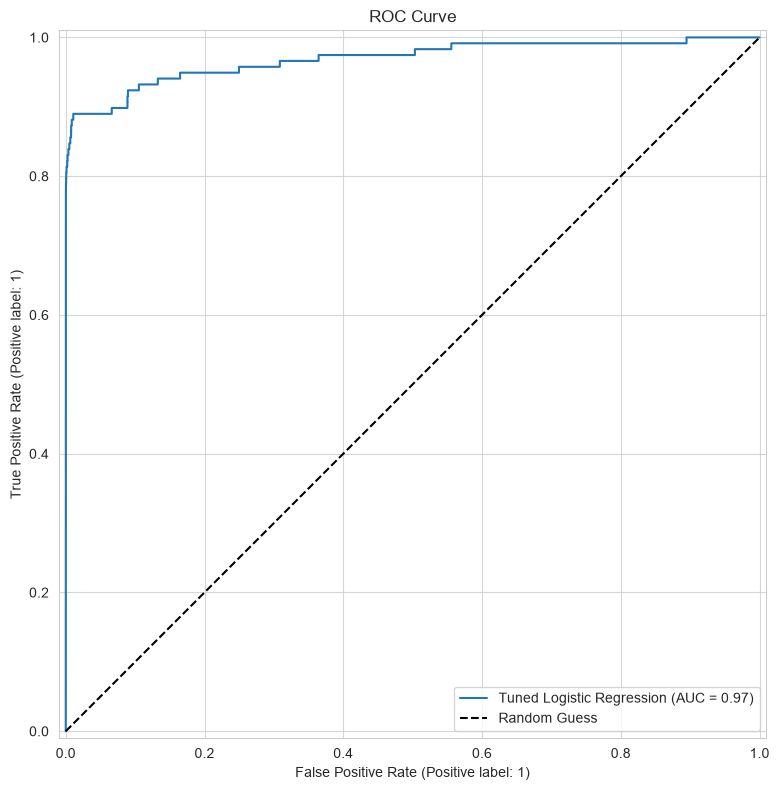

In [13]:
plot_roc_curve(_lr, xtest_scaled, ytest, 'Tuned Logistic Regression')

## Confusion Matrix

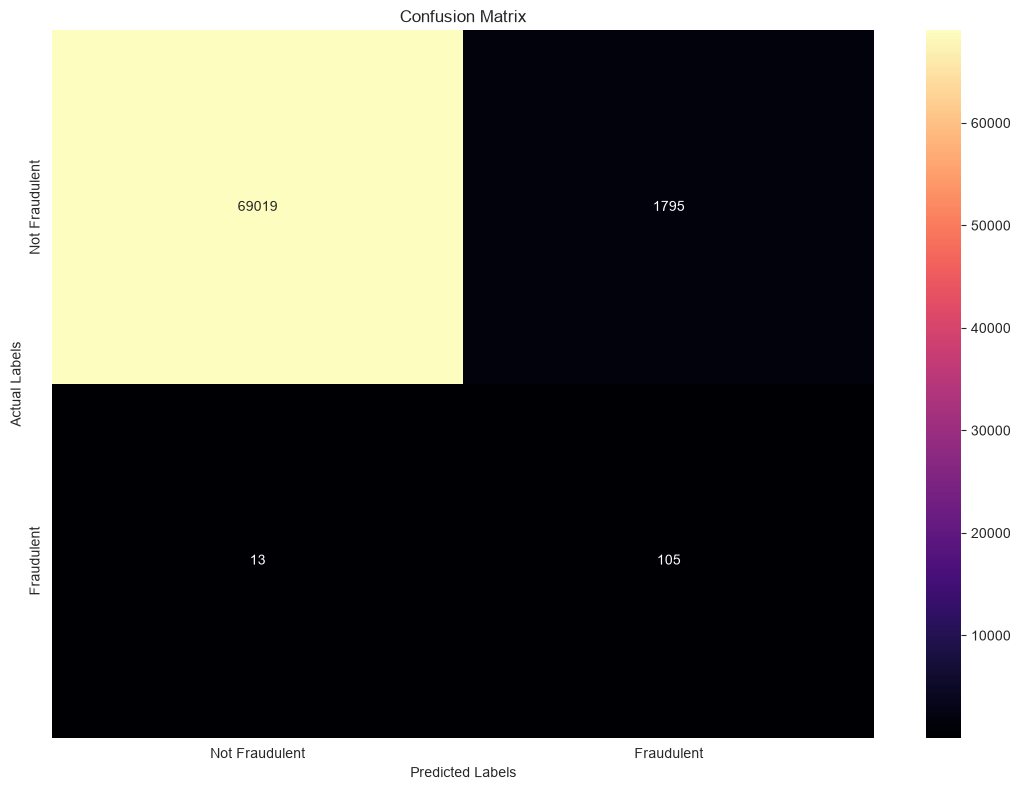

In [14]:
conf_matrix(ytest, lr_predict, ['Not Fraudulent', 'Fraudulent'])

## Classification Report

In [16]:
print(classification_report(ytest, lr_predict))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     70814
           1       0.06      0.89      0.10       118

    accuracy                           0.97     70932
   macro avg       0.53      0.93      0.55     70932
weighted avg       1.00      0.97      0.99     70932



## SMOTE Sampling and Evaluation

In [23]:
smote = SMOTE(random_state=42)

xtrain_smote, ytrain_smote = smote.fit_resample(xtrain_scaled, ytrain)

lr = LogisticRegression(
    C=100, class_weight='balanced',
    penalty='l1', solver='saga'
)

lr.fit(xtrain_smote, ytrain_smote)
yhat = lr.predict(xtest_scaled)
yhat_prob = lr.predict_proba(xtest_scaled)[:,1]

lr_smote = pd.DataFrame({
    'Smote ROC AUC Score' : [roc_auc_score(ytest, yhat_prob)],
    'Smote Train Score' : [lr.score(xtrain_smote, ytrain_smote)],
    'Smote Test Score' : [accuracy_score(ytest, yhat)]
})

print(lr_smote)

c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


   Smote ROC AUC Score  Smote Train Score  Smote Test Score
0             0.967527           0.945702          0.972185


c:\Users\LEI\Documents\Credit Card Fraud Detection\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [27]:
# class report
print(classification_report(ytest, yhat))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     70814
           1       0.05      0.88      0.10       118

    accuracy                           0.97     70932
   macro avg       0.53      0.93      0.54     70932
weighted avg       1.00      0.97      0.98     70932



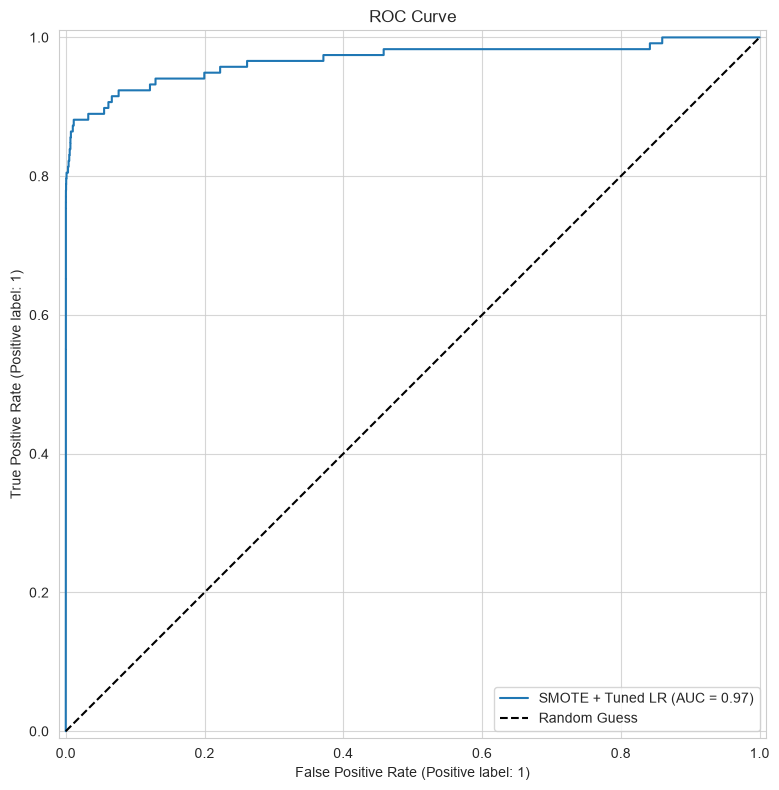

In [25]:
plot_roc_curve(lr, xtest_scaled, ytest, 'SMOTE + Tuned LR')

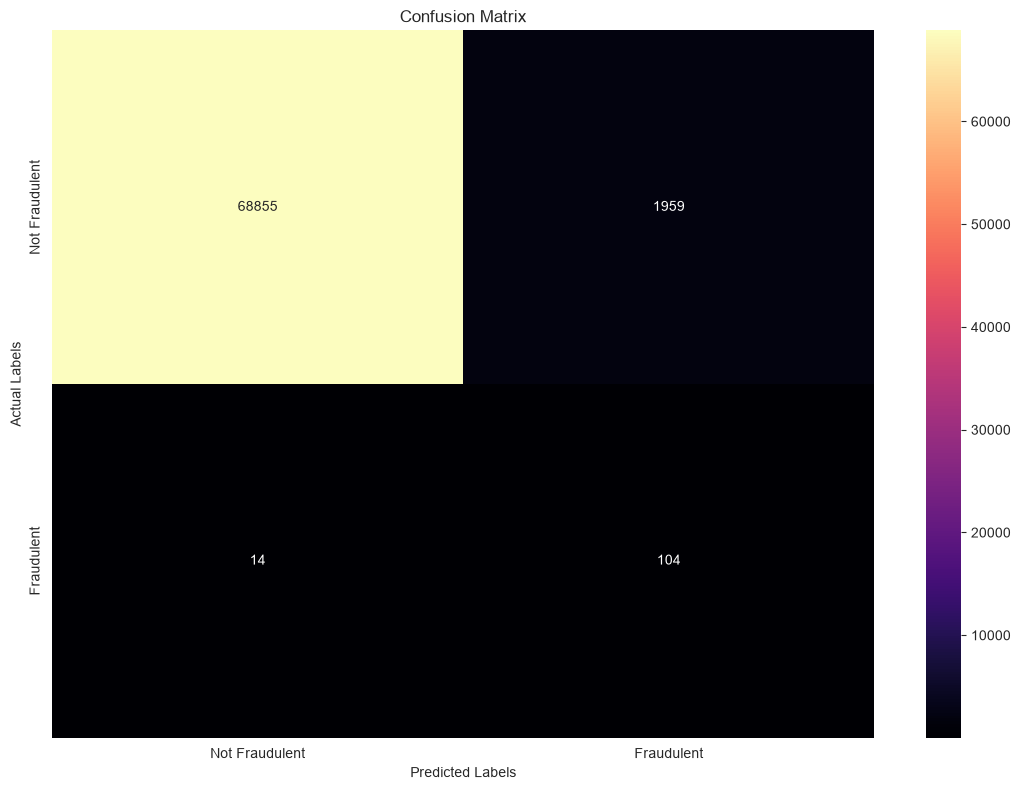

In [28]:
conf_matrix(ytest, yhat, ['Not Fraudulent', 'Fraudulent'])